# 🎓 Student Performance Analysis
This notebook explores the **Student Performance Dataset (Math course)** — a collection of student attributes such as study time, gender, family background, and three period grades (G1, G2, G3) from a Portuguese secondary school.

Each code cell is followed by a **markdown explanation** describing what the code does and why.

---
## 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd

**What this does:**  
We import two core Python libraries:
- **NumPy (`np`)** — provides fast numerical operations on arrays and matrices. Used behind the scenes for math-heavy tasks.
- **Pandas (`pd`)** — the main tool for loading, cleaning, and transforming tabular data (DataFrames). This is the backbone of our analysis.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

**What this does:**  
We import two visualization libraries:
- **Matplotlib (`plt`)** — the foundational Python plotting library. We use it for histograms, setting titles, axis labels, and displaying figures.
- **Seaborn (`sns`)** — built on top of Matplotlib, it makes statistical visualizations (bar charts, scatter plots with regression lines) easier and more visually polished.

---
## 2. Loading the Dataset

In [8]:
from google.colab import drive
import pandas as pd

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Path to your CSV file in Drive
csv_path = '/content/drive/MyDrive/student/student-mat.csv'

# 3. Load with semicolon delimiter
df = pd.read_csv(csv_path, sep=";")

# 4. Preview first few rows
df.head()


Mounted at /content/drive


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


**What this does:**  
We load the student dataset from a CSV file into a Pandas DataFrame called `df`.

- `sep=";"` tells Pandas to split columns on semicolons (`;`) instead of the usual commas — this dataset uses semicolons as its delimiter.
- `df.head()` displays the first 5 rows so we can quickly verify the file loaded correctly and check the column names and sample values.

The dataset has **33 columns** covering demographics (age, sex, address), family background (Medu, Fedu, famsize), lifestyle (studytime, goout, absences), and three period grades: **G1**, **G2**, and **G3** (final grade, scale 0–20).

---
## 3. Checking for Missing Values

In [9]:
print(df.isnull().values.any())

False


**What this does:**  
Before doing any analysis, we check if the dataset has any missing (NaN) values.

- `df.isnull()` creates a DataFrame of the same shape with `True` where a value is missing and `False` where it is present.
- `.values.any()` collapses this to a single `True` or `False`.

**Result — `False`:** The dataset is complete with no missing values, so we can proceed without imputation or dropping rows. ✅

---
## 4. Detecting Duplicate Rows

In [10]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
390,False
391,False
392,False
393,False


**What this does:**  
`df.duplicated()` returns a boolean Series — one value per row — indicating whether that row is an exact duplicate of a previous row. `True` means the row is a duplicate; `False` means it is unique.

This gives us a row-by-row view, but it's hard to read for 395 rows. The next step summarizes it.

In [11]:
# Count total duplicate rows
print("Total duplicates:", df.duplicated().sum())

# Show the actual duplicate rows
print(df[df.duplicated()])

Total duplicates: 0
Empty DataFrame
Columns: [school, sex, age, address, famsize, Pstatus, Medu, Fedu, Mjob, Fjob, reason, guardian, traveltime, studytime, failures, schoolsup, famsup, paid, activities, nursery, higher, internet, romantic, famrel, freetime, goout, Dalc, Walc, health, absences, G1, G2, G3]
Index: []

[0 rows x 33 columns]


**What this does:**  
- `.sum()` on a boolean Series counts the `True` values — i.e., the number of duplicate rows.
- `df[df.duplicated()]` filters and displays the actual duplicate rows so we can inspect them.

**Result — `Total duplicates: 0`:** There are no duplicate rows in this dataset, so no rows need to be dropped.

---
## 5. Removing Duplicates (Precautionary Step)

In [12]:
# Remove duplicate rows
df_clean = df.drop_duplicates()

# If you want to keep only the first occurrence
df_clean = df.drop_duplicates(keep="first")

# If you want to keep the last occurrence
df_clean = df.drop_duplicates(keep="last")

**What this does:**  
`drop_duplicates()` removes exact duplicate rows from the DataFrame. The `keep` parameter controls which copy survives:
- `keep="first"` (default) — keeps the first occurrence, removes all later duplicates.
- `keep="last"` — keeps the last occurrence, removes all earlier duplicates.
- `keep=False` — removes **all** copies of duplicated rows.

Even though no duplicates were found, this is a standard defensive data-cleaning step included in any robust pipeline.

In [13]:
print("Rows before:", len(df))
print("Rows after:", len(df_clean))

Rows before: 395
Rows after: 395


**What this does:**  
We confirm the cleanup by comparing row counts before and after.

**Result — `Rows before: 395` / `Rows after: 395`:** As expected, the count is unchanged because there were no duplicates. Both numbers should match.

---
## 6. Exploring the Dataset Structure

In [14]:
# Shape: number of rows and columns
print("Dataset shape:", df.shape)

# Data types of each column
print("\nColumn data types:")
print(df.dtypes)

# Quick overview of structure
print("\nInfo summary:")
print(df.info())

Dataset shape: (395, 33)

Column data types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

Info summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex

**What this does:**  
Before diving into analysis, we understand the shape and types of our data:

- **`df.shape`** → `(395, 33)` — 395 students, 33 attributes per student.
- **`df.dtypes`** — lists each column's data type. Numeric columns (age, studytime, G1, G2, G3, etc.) show as `int64`; text columns (school, sex, address, etc.) show as `object`.
- **`df.info()`** — combines column names, non-null counts, and types in one view. It also shows memory usage, which is useful for large datasets.

This step helps spot columns that may need type conversion or special handling before analysis.

---
## 7. Average Final Grade (G3)

In [15]:
avg_final_grade = df['G3'].mean()
print("the avg final grade is :", avg_final_grade)

the avg final grade is : 10.415189873417722


**What this does:**  
`df['G3']` selects the final period grade column. `.mean()` calculates the arithmetic average across all 395 students.

**Result — `~10.4`:** The average final grade is about 10.4 out of 20, giving a class-wide performance baseline. This is roughly a passing grade (≥10 is typically passing in the Portuguese system).

---
## 8. Students Scoring Above 15

In [16]:
above15 = (df['G3'] > 15).sum()

In [17]:
print(above15)

40


In [18]:
df[df['G3'] > 15].head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
14,GP,M,15,U,GT3,A,2,2,other,other,...,4,5,2,1,1,3,0,14,16,16
22,GP,M,16,U,LE3,T,4,2,teacher,other,...,4,5,1,1,3,5,2,15,15,16
31,GP,M,15,U,GT3,T,4,4,services,services,...,4,3,1,1,1,5,0,17,16,17
32,GP,M,15,R,GT3,T,4,3,teacher,at_home,...,4,5,2,1,1,5,0,17,16,16


**What this does:**  
We identify high-performing students — those with a final grade above 15 (out of 20).

- `df['G3'] > 15` creates a boolean mask (True/False per row).
- `.sum()` counts the `True` values — the number of students who scored above 15.
- `df[df['G3'] > 15].head()` displays the first 5 of those high-scoring student records.

**Result — `40` students** scored above 15, representing roughly 10% of the class.

---
## 9. Correlation: Study Time vs Final Grade

In [19]:
# Correlation coefficient between studytime and G3
corr_value = df['studytime'].corr(df['G3'])
print("Correlation between study time and final grade:", corr_value)

Correlation between study time and final grade: 0.09781968965319626


**What this does:**  
`.corr()` computes the **Pearson correlation coefficient** between two columns. It measures linear relationship strength, ranging from -1 to +1:

| Value | Meaning |
|---|---|
| Close to **+1** | Strong positive relationship |
| Close to **0** | Little/no linear relationship |
| Close to **-1** | Strong negative relationship |

**Result — `~0.098`:** A weak positive correlation. Studying more is *slightly* associated with higher grades, but the relationship is not strong. Other factors (prior failures, absences, family support) likely matter more.

---
## 10. Average Grade by Gender

In [20]:
# Average final grade by gender
avg_by_gender = df.groupby("sex")["G3"].mean()
print(avg_by_gender)

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


**What this does:**  
- `df.groupby("sex")` splits the DataFrame into two groups: `"F"` (female) and `"M"` (male).
- `["G3"].mean()` computes the average final grade within each group.

**Result:**
- Female (F): **~9.97**
- Male (M): **~10.91**

Male students have a slightly higher average final grade in this dataset. However, this difference is modest and should not be generalized without statistical significance testing.

---
## 11. Bar Chart — Average Final Grade by Gender

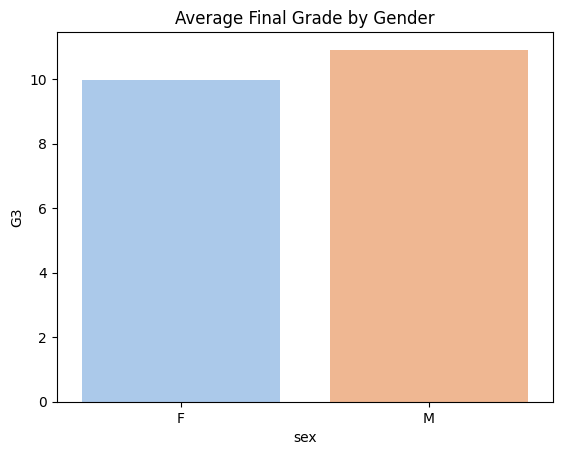

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x="sex",
    y="G3",
    data=df,
    errorbar=None,
    hue="sex",
    palette="pastel",
    legend=False
)

plt.title("Average Final Grade by Gender")
plt.show()

**What this does:**  
This bar chart visually compares average final grades between female and male students.

Key parameters:
- **`x="sex"`** — places gender categories on the x-axis.
- **`y="G3"`** — plots average G3 grade on the y-axis.
- **`errorbar=None`** — removes confidence interval bars to keep the chart clean.
- **`hue="sex"`** — applies per-group colour (required in newer Seaborn versions).
- **`palette="pastel"`** — uses soft, readable colours.
- **`legend=False`** — hides the redundant colour legend since the x-axis labels already identify the groups.

A bar chart is appropriate here because gender is a **categorical variable** and we're comparing a single numeric summary (the mean) across categories.

---
## 12. Histogram — Distribution of Final Grades

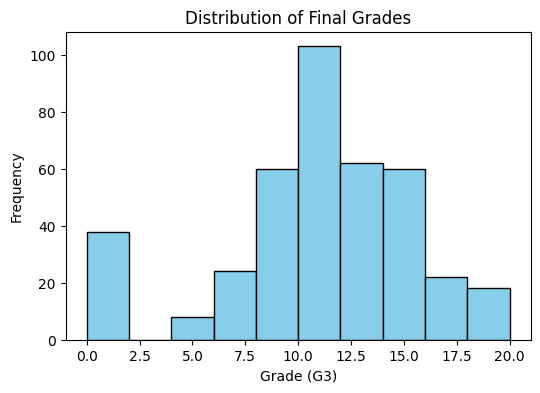

In [22]:

plt.figure(figsize=(6,4))
plt.hist(df['G3'], bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Final Grades")
plt.xlabel("Grade (G3)")
plt.ylabel("Frequency")
plt.show()

**What this does:**  
A histogram shows how final grades are **spread across the class**.

Key parameters:
- **`bins=10`** — splits the 0–20 grade range into 10 equal-width intervals.
- **`color='skyblue'`** and **`edgecolor='black'`** — make bars visually distinct.

**What to look for:**
- **Peak near 0** — this dataset has a notable spike at grade 0, representing students who did not sit the final exam.
- **Central cluster** — most students score in the 8–14 range, consistent with the ~10.4 average.
- **Right tail** — a small group of high-achievers scores above 16.

---
## 13. Scatter Plot — Study Time vs Final Grade by Gender

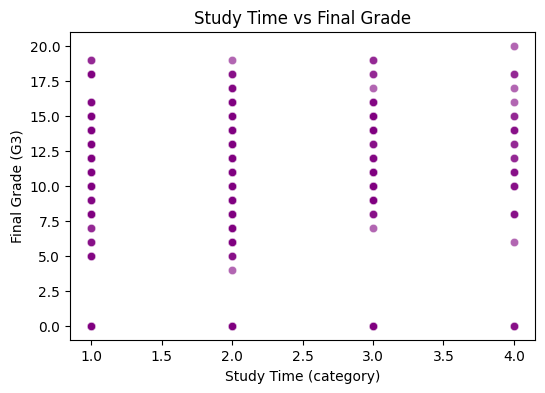

In [27]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="studytime", y="G3", data=df, color="purple", alpha=0.6)
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time (category)")
plt.ylabel("Final Grade (G3)")
plt.show()

 14. Bar chart: male vs female average score

/tmp/ipykernel_910/3823091206.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="sex", y="G3", data=df, errorbar=None, palette="pastel")


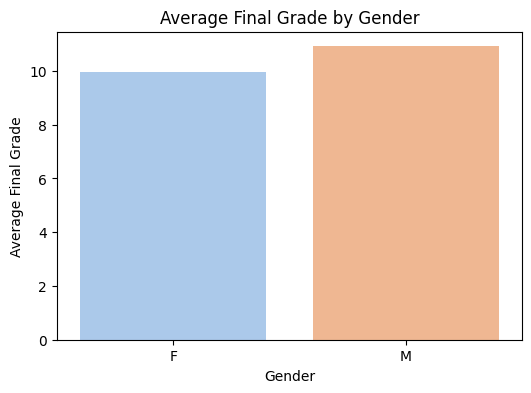

In [24]:
plt.figure(figsize=(6,4))
sns.barplot(x="sex", y="G3", data=df, errorbar=None, palette="pastel")
plt.title("Average Final Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Final Grade")
plt.show()

**What this does:**  
`sns.lmplot()` combines a **scatter plot** with a **linear regression line** for each group.

Key parameters:
- **`x="studytime"`, `y="G3"`** — each dot is one student, plotted by their weekly study time (1–4 scale) vs their final grade.
- **`hue="sex"`** — colours points by gender and draws a separate regression line for each group.
- **`markers=["o", "s"]`** — uses circles for one gender and squares for the other, making groups distinguishable even in greyscale or for colour-blind readers.
- **`palette="Set2"`** — a colour-blind-friendly palette.

**What this tells us:**  
The regression lines show the direction of the study time–grade relationship for each gender separately. Both lines trend slightly upward (consistent with the weak positive correlation found in Step 9), and we can see whether this trend differs between female and male students.

---
## Summary

| Step | Purpose | Key Finding |
|---|---|---|
| Import libraries | Set up tools | — |
| Load data | Read CSV into DataFrame | 395 students, 33 columns |
| Check nulls | Confirm completeness | No missing values |
| Detect duplicates | Ensure uniqueness | No duplicates |
| Remove duplicates | Clean defensively | Row count unchanged |
| Explore structure | Understand data types | 16 numeric, 17 text columns |
| Average grade | Class baseline | ~10.4 / 20 |
| High scorers | Count top students | 40 students scored > 15 |
| Correlation | Study time vs grade | Weak positive (~0.098) |
| Gender groupby | Compare averages | Males slightly higher |
| Bar chart | Visualise gender gap | Clear but small difference |
| Histogram | Grade distribution | Peak at 0; cluster at 8–14 |
| lmplot | Study–grade by gender | Both groups trend upward |